In [ ]:
import pandas as pd
import numpy as np

In [ ]:
match=pd.read_csv("matches.csv")
delivery=pd.read_csv("deliveries.csv")

In [ ]:
total_score_df=delivery.groupby(["match_id","inning"]).sum()["total_runs"].reset_index()

In [ ]:
total_score_df

,match_id,inning,total_runs
0,1,1,207.0
1,1,2,172.0
2,2,1,184.0
3,2,2,187.0
4,3,1,183.0
...,...,...,...
85,42,2,119.0
86,43,1,148.0
87,43,2,136.0
88,44,1,212.0


In [ ]:
total_score_df=total_score_df[total_score_df["inning"]==1]

In [ ]:
match_df=match.merge(total_score_df[["match_id","total_runs"]],left_on="id",right_on="match_id")

In [ ]:
teams=[
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Punjab Kings',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [ ]:
match_df["team1"]=match_df["team1"].str.replace("Delhi Daredevils","Delhi Capitals")
match_df["team2"]=match_df["team2"].str.replace("Delhi Daredevils","Delhi Capitals")

match_df["team1"]=match_df["team1"].str.replace("Deccan Chargers","Sunrisers Hyderabad")
match_df["team2"]=match_df["team2"].str.replace("Deccan Chargers","Sunrisers Hyderabad")

match_df["team1"]=match_df["team1"].str.replace("Kings XI Punjab","Punjab Kings")
match_df["team2"]=match_df["team2"].str.replace("Kings XI Punjab","Punjab Kings")

In [ ]:
match_df=match_df[match_df["team1"].isin(teams)]
match_df=match_df[match_df["team2"].isin(teams)]

In [ ]:
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207.0
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157.0
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,7,178.0
7,8,IPL-2017,Indore,10-04-2017,Royal Challengers Bangalore,Punjab Kings,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,8,148.0
9,10,IPL-2017,Mumbai,12-04-2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,10,158.0
10,11,IPL-2017,Kolkata,13-04-2017,Punjab Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,8,SP Narine,Eden Gardens,A Deshmukh,NJ Llong,NaN,11,170.0
11,12,IPL-2017,Bangalore,14-04-2017,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,KA Pollard,M Chinnaswamy Stadium,KN Ananthapadmanabhan,AK Chaudhary,NaN,12,142.0
13,14,IPL-2017,Kolkata,15-04-2017,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Kolkata Knight Riders,17,0,RV Uthappa,Eden Gardens,AY Dandekar,NJ Llong,NaN,14,172.0
14,15,IPL-2017,Delhi,15-04-2017,Delhi Capitals,Punjab Kings,Delhi Daredevils,bat,normal,0,Delhi Daredevils,51,0,CJ Anderson,Feroz Shah Kotla,YC Barde,Nitin Menon,NaN,15,188.0
17,18,IPL-2017,Delhi,17-04-2017,Delhi Capitals,Kolkata Knight Riders,Delhi Daredevils,bat,normal,0,Kolkata Knight Riders,0,4,NM Coulter-Nile,Feroz Shah Kotla,Nitin Menon,CK Nandan,NaN,18,168.0


In [ ]:
match_df=match_df[match_df["dl_applied"]==0]

In [ ]:
match_df=match_df[["match_id","city","winner","total_runs"]]


In [ ]:
delivery_df=match_df.merge(delivery,on="match_id")
delivery_df = delivery_df.rename(columns={"ball s_left": "balls_left"})

In [ ]:
delivery_df=delivery_df[delivery_df["inning"]==2]

In [ ]:
delivery_df["current_score"] =delivery_df.groupby("match_id")["total_runs_y"].cumsum()

<ipython-input-75-0de25a378116>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["current_score"] =delivery_df.groupby("match_id")["total_runs_y"].cumsum()


In [ ]:
delivery_df["runs_left"]=delivery_df["total_runs_x"]-delivery_df["current_score"]

<ipython-input-76-2395b07bad7b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["runs_left"]=delivery_df["total_runs_x"]-delivery_df["current_score"]


In [ ]:
delivery_df["balls_left"]=126-(delivery_df["over"]*6 + delivery_df["ball"])

<ipython-input-77-8910fe9dd46a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["balls_left"]=126-(delivery_df["over"]*6 + delivery_df["ball"])


In [ ]:
delivery_df["player_dismissed"]=delivery_df["player_dismissed"].fillna("0")
delivery_df["player_dismissed"]=delivery_df["player_dismissed"].apply(lambda x:x if x=="0" else "1")
delivery_df["player_dismissed"]=delivery_df["player_dismissed"].astype("int")
wickets=delivery_df.groupby("match_id")["player_dismissed"].cumsum().values
delivery_df["wickets"]=10-wickets

<ipython-input-78-cc5cf971b147>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["player_dismissed"]=delivery_df["player_dismissed"].fillna("0")
<ipython-input-78-cc5cf971b147>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["player_dismissed"]=delivery_df["player_dismissed"].apply(lambda x:x if x=="0" else "1")
<ipython-input-78-cc5cf971b147>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [ ]:
delivery_df["crr"]=(delivery_df["current_score"]*6)/(120-delivery_df["ball"])
delivery_df = delivery_df.rename(columns={"ball s_left": "balls_left"})

<ipython-input-79-3c386b123a29>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df["crr"]=(delivery_df["current_score"]*6)/(120-delivery_df["ball"])


In [ ]:
delivery_df["rrr"]=(delivery_df["runs_left"]*6)/delivery_df["balls_left"]

In [ ]:
def result(row):
  return 1 if row["batting_team"] == row["winner"] else 0

In [ ]:
delivery_df["result"]=delivery_df.apply(result,axis=1)

# axis=1 (Apply to Rows):

# The function is applied to each row independently.
# The function receives a pandas Series representing a row of the DataFrame.

In [ ]:
final_df=delivery_df[["batting_team","bowling_team","city","runs_left","balls_left","wickets","total_runs_x","crr","rrr","result"]]
final_df.sample(5)

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
112470,Chennai Super Kings,Kings XI Punjab,Chandigarh,37,46,8,130,4.728814,4.826087,1
21239,Royal Challengers Bangalore,Deccan Chargers,Cape Town,183,118,9,184,0.050847,9.305085,0
6042,Kolkata Knight Riders,Kings XI Punjab,Chandigarh,66,37,7,167,5.269565,10.702703,0
103895,Chennai Super Kings,Mumbai Indians,Mumbai,37,42,7,183,7.684211,5.285714,1
92405,Kolkata Knight Riders,Rajasthan Royals,Ahmedabad,170,119,10,170,0.000000,8.571429,0


In [ ]:

final_df = final_df.rename(columns={"ball s_left": "balls_left"})
final_df.sample(final_df.shape[0])

# Code Explanation

# final_df:

# A pandas DataFrame.
# sample():

# The sample() method in pandas is used to randomly select rows from the DataFrame.
# By default, it selects rows without replacement.
# final_df.shape[0]:

# final_df.shape gives a tuple (number_of_rows, number_of_columns) of the DataFrame.
# final_df.shape[0] refers to the total number of rows in the DataFrame.
# sample(final_df.shape[0]):

# Tells pandas to select the same number of rows as the total number of rows in final_df.
# As a result, this shuffles all rows of the DataFrame randomly.

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
77750,Delhi Daredevils,Kings XI Punjab,Dharamsala,160,106,10,171,0.559322,9.056604,0
104302,Kolkata Knight Riders,Kings XI Punjab,Pune,139,108,10,155,0.842105,7.722222,1
96872,Rajasthan Royals,Mumbai Indians,Ahmedabad,110,62,5,178,3.517241,10.645161,0
63022,Royal Challengers Bangalore,Kings XI Punjab,Chandigarh,48,32,7,163,5.948276,9.000000,1
100408,Chennai Super Kings,Kings XI Punjab,Mumbai,121,74,7,226,5.431034,9.810811,0
...,...,...,...,...,...,...,...,...,...,...
113715,Chennai Super Kings,Royal Challengers Bangalore,Ranchi,139,119,10,139,0.000000,7.008403,1
89662,Chennai Super Kings,Mumbai Indians,NaN,62,50,8,141,4.086207,7.440000,1
38316,Rajasthan Royals,Deccan Chargers,Ahmedabad,140,112,10,148,0.406780,7.500000,1
29294,Deccan Chargers,Delhi Daredevils,Durban,144,109,10,173,1.513043,7.926606,0


In [ ]:
final_df.isnull().sum()

,0
batting_team,0
bowling_team,0
city,832
runs_left,0
balls_left,0
wickets,0
total_runs_x,0
crr,0
rrr,7
result,0


In [ ]:
final_df.dropna(inplace=True)

In [ ]:
final_df=final_df[final_df['balls_left'] !=0]

In [ ]:
x=final_df.iloc[:,:-1]
y=final_df.iloc[:,-1]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=0)



In [ ]:
# x_train

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

trf = ColumnTransformer([
    ('trf',OneHotEncoder(sparse_output=False,drop='first'),['batting_team','bowling_team','city'])
]
,remainder='passthrough')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
pipe=Pipeline(steps=[
    ('step1',trf),
    ('step2', LogisticRegression(solver="liblinear"))
])

In [ ]:
pipe.fit(x_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', LogisticRegression(solver='liblinear'))])

In [ ]:
y_pred=pipe.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.80489172331628

In [ ]:
pipe.predict_proba(x_test)[1]*100

array([52.39268647, 47.60731353])

In [ ]:
def match_summary(row):
    print("Batting Team-" + row['batting_team'] + " | Bowling Team-" + row['bowling_team'] + " | Target- " + str(row['total_runs_x']))


In [ ]:
def match_progression(x_df,match_id,pipe):
    match = x_df[x_df['match_id'] == match_id]
    match = match[(match['ball'] == 6)]
    temp_df = match[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr']].dropna()
    temp_df = temp_df[temp_df['balls_left'] != 0]
    result = pipe.predict_proba(temp_df)
    temp_df['lose'] = np.round(result.T[0]*100,1)
    temp_df['win'] = np.round(result.T[1]*100,1)
    temp_df['end_of_over'] = range(1,temp_df.shape[0]+1)

    target = temp_df['total_runs_x'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs.insert(0,target)
    temp_df['runs_after_over'] = np.array(runs)[:-1] - np.array(new_runs)
    wickets = list(temp_df['wickets'].values)
    new_wickets = wickets[:]
    new_wickets.insert(0,10)
    wickets.append(0)
    w = np.array(wickets)
    nw = np.array(new_wickets)
    temp_df['wickets_in_over'] = (nw - w)[0:temp_df.shape[0]]

    print("Target-",target)
    temp_df = temp_df[['end_of_over','runs_after_over','wickets_in_over','lose','win']]
    return temp_df,target


In [ ]:

temp_df,target = match_progression(delivery_df,74,pipe)
temp_df

Target- 178


,end_of_over,runs_after_over,wickets_in_over,lose,win
10459,1,4,0,56.4,43.6
10467,2,8,0,51.9,48.1
10473,3,1,0,58.2,41.8
10479,4,7,1,70.2,29.8
10485,5,12,0,60.5,39.5
10491,6,13,0,48.4,51.6
10497,7,9,0,42.4,57.6
10505,8,15,0,28.3,71.7
10511,9,7,0,26.0,74.0
10518,10,17,0,14.3,85.7


Text(0.5, 1.0, 'Target-178')

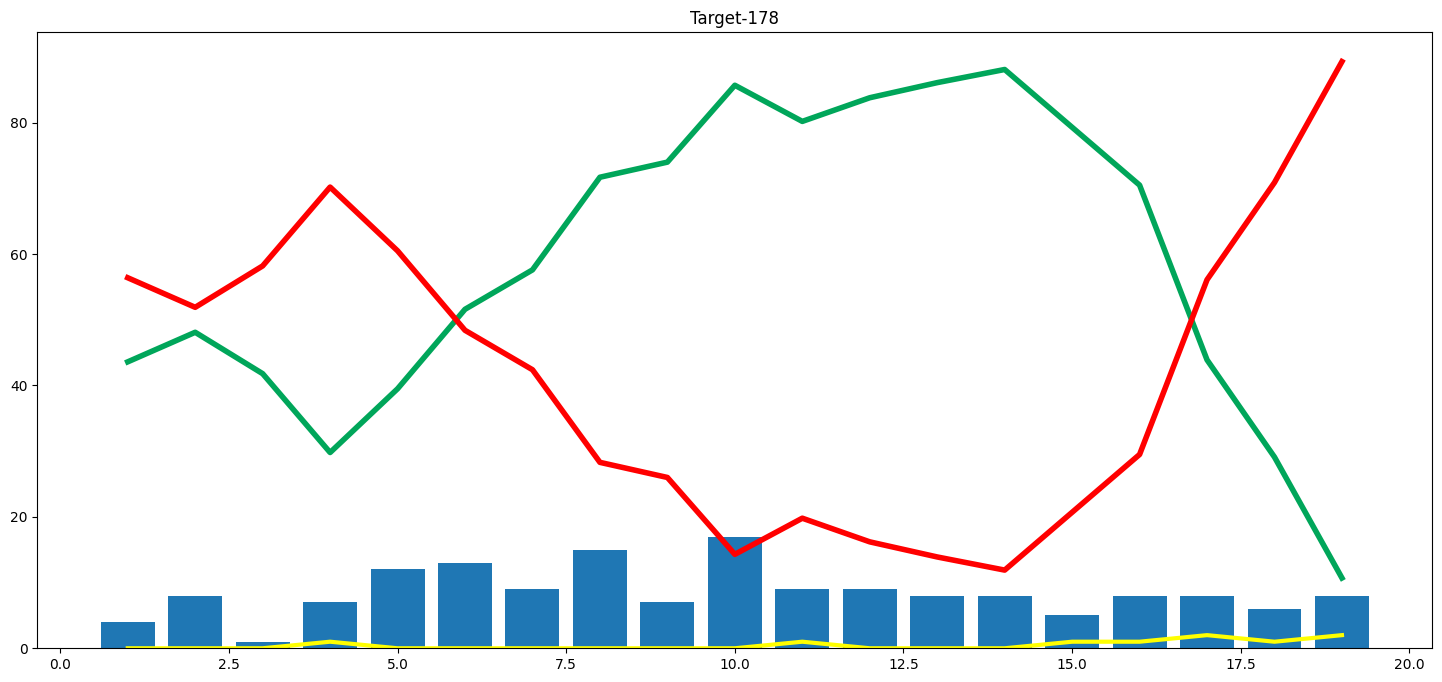

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(18,8))
plt.plot(temp_df['end_of_over'],temp_df['wickets_in_over'],color='yellow',linewidth=3)
plt.plot(temp_df['end_of_over'],temp_df['win'],color='#00a65a',linewidth=4)
plt.plot(temp_df['end_of_over'],temp_df['lose'],color='red',linewidth=4)
plt.bar(temp_df['end_of_over'],temp_df['runs_after_over'])
plt.title('Target-' + str(target))

In [ ]:
teams

['Sunrisers Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Punjab Kings',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals']

In [ ]:
delivery_df['city'].unique()

array(['Hyderabad', 'Bangalore', 'Mumbai', 'Indore', 'Kolkata', 'Delhi',
       'Chandigarh', 'Jaipur', 'Chennai', 'Cape Town', 'Port Elizabeth',
       'Durban', 'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi', 'Abu Dhabi',
       'Sharjah', nan, 'Mohali', 'Bengaluru'], dtype=object)

In [ ]:
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))